# Eksperimen Preprocessing - Ayudha

---

## 1. Perkenalan Dataset


**Asal Dataset:**
Dataset **Wine** tersedia dalam pustaka [Scikit-Learn](https://scikit-learn.org/stable/datasets/toy_dataset.html?utm_source=chatgpt.com#wine-dataset) melalui fungsi `load_wine()`. Dataset ini berisi hasil pengukuran kandungan kimia dari beberapa sampel wine yang diproduksi di wilayah Italia dengan tiga varietas anggur yang berbeda.

### Detail Dataset

* **Total sampel:** 178 data wine
* **Total atribut/f fitur:** 13 fitur numerik
* **Jumlah kategori kelas:** 3 kategori wine
* **Kolom label/target:** `target`

### Deskripsi Permasalahan

Dataset ini digunakan untuk membangun model machine learning yang mampu mengidentifikasi kategori wine berdasarkan karakteristik kimianya.

* **Jenis pembelajaran:** Supervised Learning
* **Metode:** Multiclass Classification
* **Output yang diprediksi:** Jenis wine (`class 0`, `class 1`, atau `class 2`) berdasarkan nilai fitur kimia yang dimiliki setiap sampel.


---
## 2. Import Library

Mengimpor library yang diperlukan untuk analisis data, visualisasi, dan preprocessing.

In [24]:
# ==========================================
# Melakukan Import Library
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_wine

# Konfigurasi style visualisasi
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
sns.set_style("whitegrid")
%matplotlib inline

print("Library berhasil diimport.")

Library berhasil diimport.


---
## 3. Memuat Dataset

Memuat dataset Wine dari file CSV dan menampilkan informasi awal dataset.

In [25]:
# ==========================================
# Load Dataset dari CSV
# ==========================================

# Path ke dataset raw
raw_data_path = "../dataset_raw/wine_raw.csv"

# Load dataset
df = pd.read_csv(raw_data_path)

# Tampilkan 5 baris pertama
print("5 Baris Pertama Dataset:")
print("=" * 60)
df.head()

5 Baris Pertama Dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [26]:
# Informasi shape dataset
print(f"Jumlah baris (sampel): {df.shape[0]}")
print(f"Jumlah kolom (fitur + target): {df.shape[1]}")
print(f"Jumlah fitur: {df.shape[1] - 1} fitur + 1 target")

Jumlah baris (sampel): 178
Jumlah kolom (fitur + target): 14
Jumlah fitur: 13 fitur + 1 target


---
## 4. Exploratory Data Analysis (EDA)

Melakukan eksplorasi dataset untuk memahami karakteristik, distribusi, dan pola yang ada dalam data.

### 4.1 Informasi Dataset

Menampilkan tipe data, jumlah non-null, dan informasi umum dataset.

In [27]:
# Informasi dataset
print("Informasi Dataset:")
print("=" * 60)
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

### 4.2 Statistik Deskriptif

Menampilkan statistik dasar seperti mean, std, min, max, dan quartile untuk setiap fitur numerik.

In [28]:
# Statistik deskriptif
print("Statistik Deskriptif:")
print("=" * 60)
df.describe()

Statistik Deskriptif:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### 4.3 Mengecekan Missing Values

Memeriksa apakah terdapat nilai yang hilang (missing values) dalam dataset.

In [29]:
# Cek missing values
print("Pengecekan Missing Values:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase (%)": missing_pct
})

if missing.sum() == 0:
    print("Tidak ada missing values. Dataset sudah bersih.")
else:
    print(missing_info[missing_info["Jumlah Missing"] > 0])

Pengecekan Missing Values:
Tidak ada missing values. Dataset sudah bersih.


### 4.4 Pengecekan Duplicate Values

Memeriksa apakah terdapat data duplikat dalam dataset.

In [52]:
# Cek duplicate values
print("Pengecekan Duplicate Values:")
print("=" * 60)
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

if duplicate_count > 0:
    print("Baris duplikat akan dihapus pada tahap Data Cleaning.")

Pengecekan Duplicate Values:
Jumlah data duplikat: 0


### 4.5 Distribusi Target

Melihat distribusi kelas target untuk mengetahui apakah dataset seimbang (balanced) atau tidak.

In [31]:
# Distribusi target
print("Distribusi Target:")
print("=" * 60)
target_counts = df["target"].value_counts().sort_index()
print(target_counts)
print(f"\nPersentase:")
print((target_counts / len(df) * 100).round(2).to_string())

Distribusi Target:
target
0    59
1    71
2    48
Name: count, dtype: int64

Persentase:
target
0    33.15
1    39.89
2    26.97


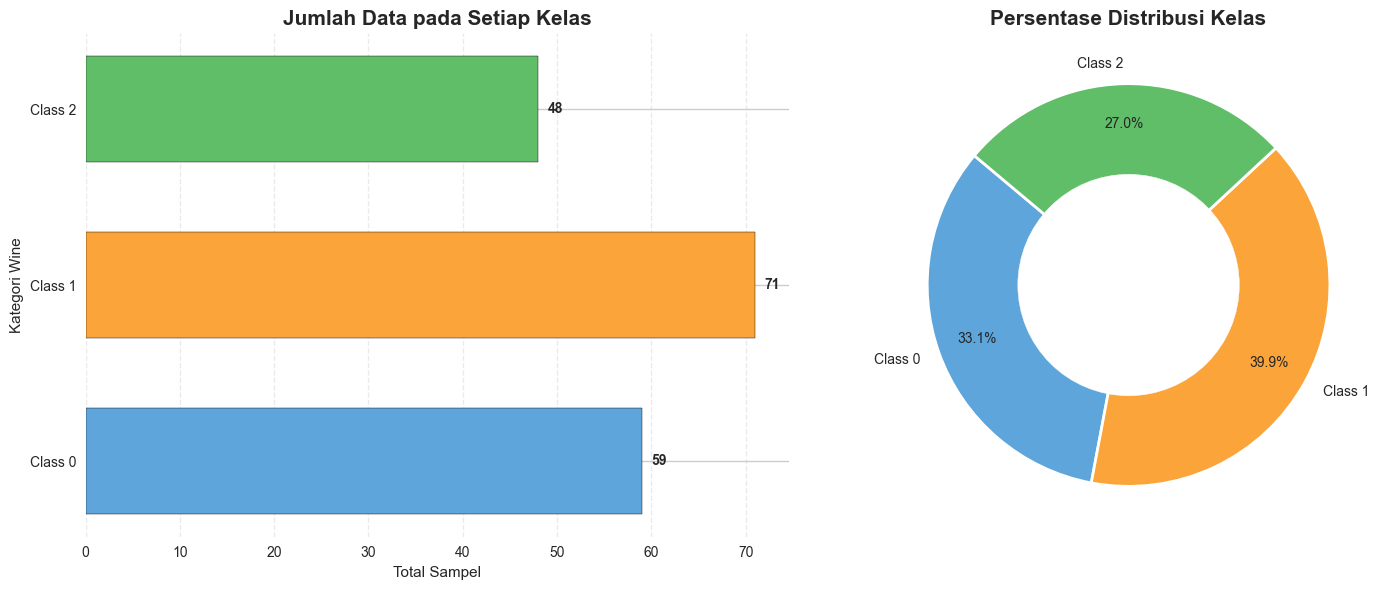

In [39]:
# ==========================================
# Visualisasi Distribusi Target Dataset Wine
# ==========================================

fig = plt.figure(figsize=(15, 6))

# Warna custom
palette = ["#5DA5DA", "#FAA43A", "#60BD68"]

# -------------------------------
# Subplot 1 : Horizontal Bar Plot
# -------------------------------
ax1 = plt.subplot(1, 2, 1)

bars = ax1.barh(
    ["Class 0", "Class 1", "Class 2"],
    target_counts.values,
    color=palette,
    edgecolor="black",
    height=0.6
)

ax1.set_title(
    "Jumlah Data pada Setiap Kelas",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("Total Sampel")
ax1.set_ylabel("Kategori Wine")

# Menambahkan label nilai
for bar in bars:
    width = bar.get_width()
    ax1.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontweight="bold"
    )

# Grid halus
ax1.grid(axis="x", linestyle="--", alpha=0.4)

# -------------------------------
# Subplot 2 : Donut Chart
# -------------------------------
ax2 = plt.subplot(1, 2, 2)

wedges, texts, autotexts = ax2.pie(
    target_counts.values,
    labels=["Class 0", "Class 1", "Class 2"],
    autopct="%1.1f%%",
    startangle=140,
    colors=palette,
    pctdistance=0.8,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

# Membuat lubang di tengah (donut)
centre_circle = plt.Circle((0, 0), 0.55, fc="white")
ax2.add_artist(centre_circle)

ax2.set_title(
    "Persentase Distribusi Kelas",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 4.6 Correlation Heatmap

Melihat korelasi antar fitur dan antara fitur dengan target. Korelasi tinggi menandakan hubungan linear yang kuat.

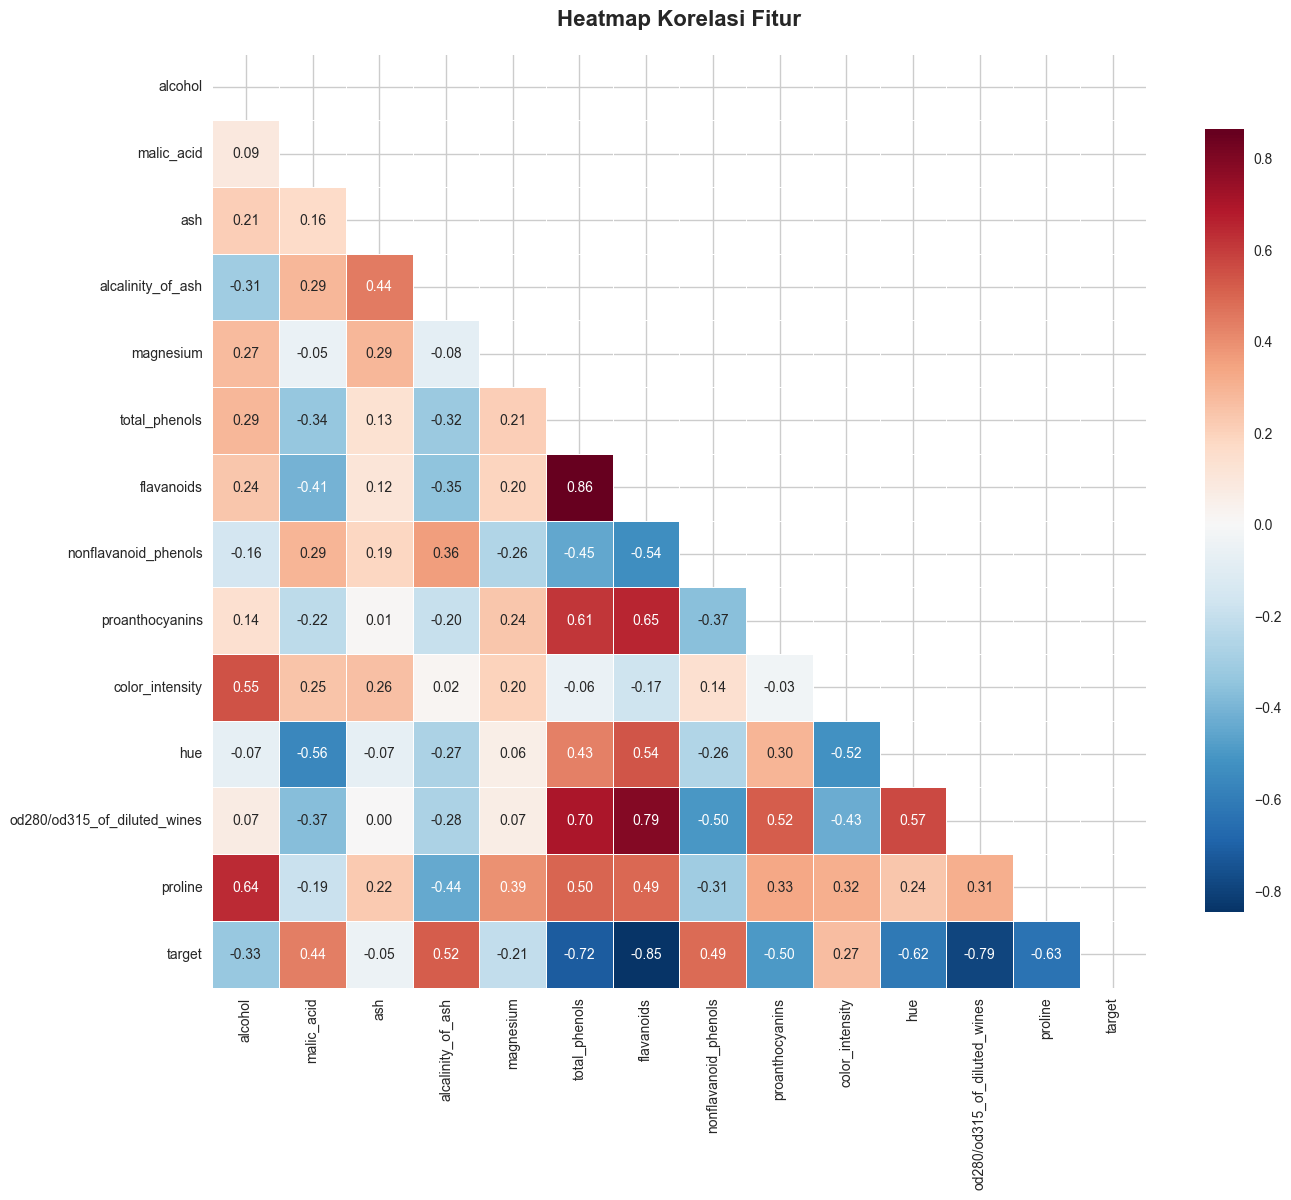

In [35]:
# Heatmap korelasi
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, square=True,
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Heatmap Korelasi Fitur", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

---
### 4.7 Data Cleaning

Tahapan pemeriksaan dan validasi data untuk memastikan dataset siap digunakan pada proses preprocessing dan tahap pemodelan.
Dataset Wine dari Scikit-Learn sudah bersih dari missing values. Namun kita tetap menyediakan kode handling untuk jaga-jaga.

In [40]:
# Handling Missing Values
print("Handling Missing Values:")
print("=" * 60)

if df.isnull().sum().sum() > 0:
    # Isi missing values numerik dengan median
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  - {col}: {df[col].isnull().sum()} missing diisi median={median_val:.4f}")
    print("\nMissing values berhasil di-handle.")
else:
    print("Tidak ada missing values. Data sudah bersih.")

print(f"\nTotal missing values saat ini: {df.isnull().sum().sum()}")

Handling Missing Values:
Tidak ada missing values. Data sudah bersih.

Total missing values saat ini: 0


### 4.8 Outlier Checking

Mendeteksi outlier menggunakan metode IQR (Interquartile Range). Outlier tidak langsung dihapus karena untuk dataset kecil seperti Wine, outlier bisa mengandung informasi penting.

In [51]:
# Deteksi outlier dengan metode IQR
print("Deteksi Outlier (Metode IQR):")
print("=" * 60)

feature_cols = [col for col in df.columns if col != "target"]
outlier_counts = {}

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=["Fitur", "Jumlah Outlier"])
outlier_df = outlier_df.sort_values("Jumlah Outlier", ascending=False)
print(outlier_df.to_string(index=False))

total_outliers = outlier_df["Jumlah Outlier"].sum()
print(f"\nTotal outlier (akumulasi): {total_outliers}")
print("Catatan: Outlier tidak dihapus karena dapat mengandung informasi penting untuk klasifikasi.")

Deteksi Outlier (Metode IQR):
                       Fitur  Jumlah Outlier
           alcalinity_of_ash               4
                   magnesium               4
             color_intensity               4
                  malic_acid               3
                         ash               3
             proanthocyanins               2
                         hue               1
                     alcohol               0
               total_phenols               0
                  flavanoids               0
        nonflavanoid_phenols               0
od280/od315_of_diluted_wines               0
                     proline               0

Total outlier (akumulasi): 21
Catatan: Outlier tidak dihapus karena dapat mengandung informasi penting untuk klasifikasi.


---
## 5. Data Preprocessing

Tahapan preprocessing untuk menyiapkan data siap pakai untuk model machine learning. Melakukan Feature Selection dan  Splitting Feature memisahkan X dan Y

Feature Selection (SelectKBest):
                       Fitur       Skor
                  flavanoids 233.925873
                     proline 207.920374
od280/od315_of_diluted_wines 189.972321
                     alcohol 135.077624
             color_intensity 120.664018
                         hue 101.316795
               total_phenols  93.733010
                  malic_acid  36.943425
           alcalinity_of_ash  35.771637
             proanthocyanins  30.271383
        nonflavanoid_phenols  27.575417
                         ash  13.312901
                   magnesium  12.429584

Fitur terpilih (10 dari 13):
['alcohol', 'malic_acid', 'alcalinity_of_ash', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


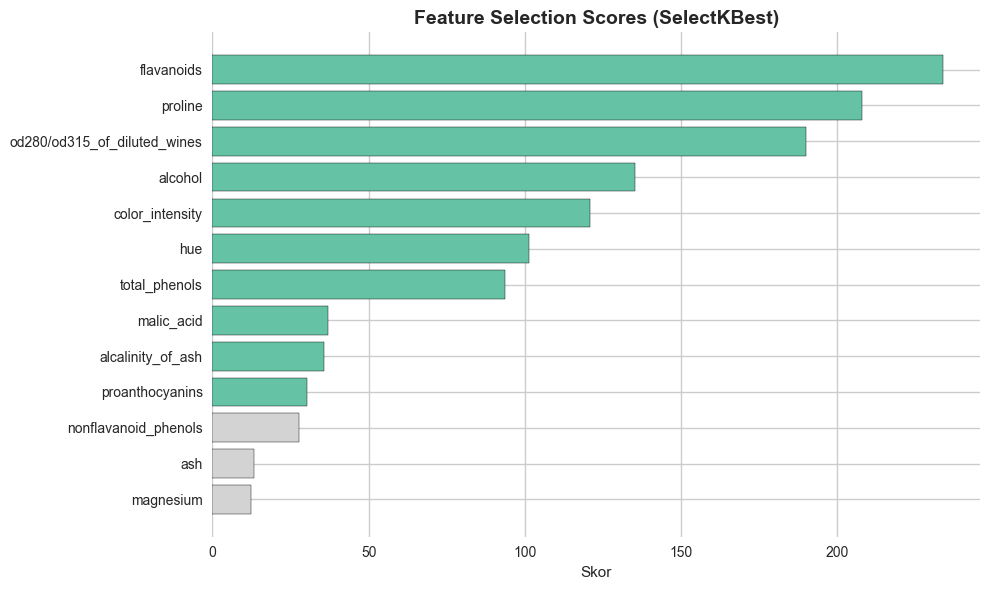

In [44]:
# Feature Selection dengan SelectKBest
print("Feature Selection (SelectKBest):")
print("=" * 60)

X = df[feature_cols]
y = df["target"]

# Pilih 10 fitur terbaik dari 13 fitur
k_features = min(10, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k_features)
X_selected = selector.fit_transform(X, y)

# Tampilkan skor fitur
feature_scores = pd.DataFrame({
    "Fitur": feature_cols,
    "Skor": selector.scores_
}).sort_values("Skor", ascending=False)

print(feature_scores.to_string(index=False))

# Fitur yang terpilih
selected_features = np.array(feature_cols)[selector.get_support()]
print(f"\nFitur terpilih ({len(selected_features)} dari {len(feature_cols)}):")
print(list(selected_features))

# Visualisasi skor fitur
plt.figure(figsize=(10, 6))
colors = ["#66c2a5" if f in selected_features else "#d3d3d3" for f in feature_scores["Fitur"]]
plt.barh(range(len(feature_scores)), feature_scores["Skor"], color=colors, edgecolor="black")
plt.yticks(range(len(feature_scores)), feature_scores["Fitur"])
plt.xlabel("Skor")
plt.title("Feature Selection Scores (SelectKBest)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# Memisahkan fitur dan target
X = df[selected_features]
y = df["target"]

print(f"Fitur (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFitur yang digunakan: {list(X.columns)}")

Fitur (X) shape: (178, 10)
Target (y) shape: (178,)

Fitur yang digunakan: ['alcohol', 'malic_acid', 'alcalinity_of_ash', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### 5.1 Train Test Split

Membagi data menjadi data training (80%) dan data testing (20%) dengan stratifikasi untuk menjaga proporsi kelas.

In [46]:
# Train-Test Split
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Hasil Train-Test Split:")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

# Cek distribusi target setelah split
print(f"\nDistribusi target training:")
print(y_train.value_counts().sort_index().to_string())
print(f"\nDistribusi target testing:")
print(y_test.value_counts().sort_index().to_string())

Hasil Train-Test Split:
X_train shape: (142, 10)
X_test shape : (36, 10)
y_train shape: (142,)
y_test shape : (36,)

Distribusi target training:
target
0    47
1    57
2    38

Distribusi target testing:
target
0    12
1    14
2    10


### 5.2 Scaling / Normalization

Melakukan standard scaling (StandardScaler) agar fitur memiliki mean=0 dan std=1. Scaling dilakukan FIT pada training data saja, lalu TRANSFORM pada testing data untuk menghindari data leakage.

Standard Scaling:
Statistik data training SETELAH scaling:
----------------------------------------
        alcohol  malic_acid  alcalinity_of_ash  total_phenols  flavanoids  \
count  142.0000    142.0000           142.0000       142.0000    142.0000   
mean     0.0000     -0.0000             0.0000         0.0000      0.0000   
std      1.0035      1.0035             1.0035         1.0035      1.0035   
min     -2.4278     -1.4580            -2.6790        -2.0892     -1.7345   
25%     -0.7521     -0.6652            -0.7199        -0.9184     -0.7989   
50%      0.0482     -0.4830            -0.0372         0.0989      0.1578   
75%      0.7359      0.7563             0.5565         0.8498      0.8324   
max      2.3241      3.1529             3.0795         2.5938      1.8497   

       proanthocyanins  color_intensity       hue  \
count         142.0000         142.0000  142.0000   
mean            0.0000           0.0000    0.0000   
std             1.0035           1.0035    1.00

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36504\3454710502.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_36504\3454710502.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")


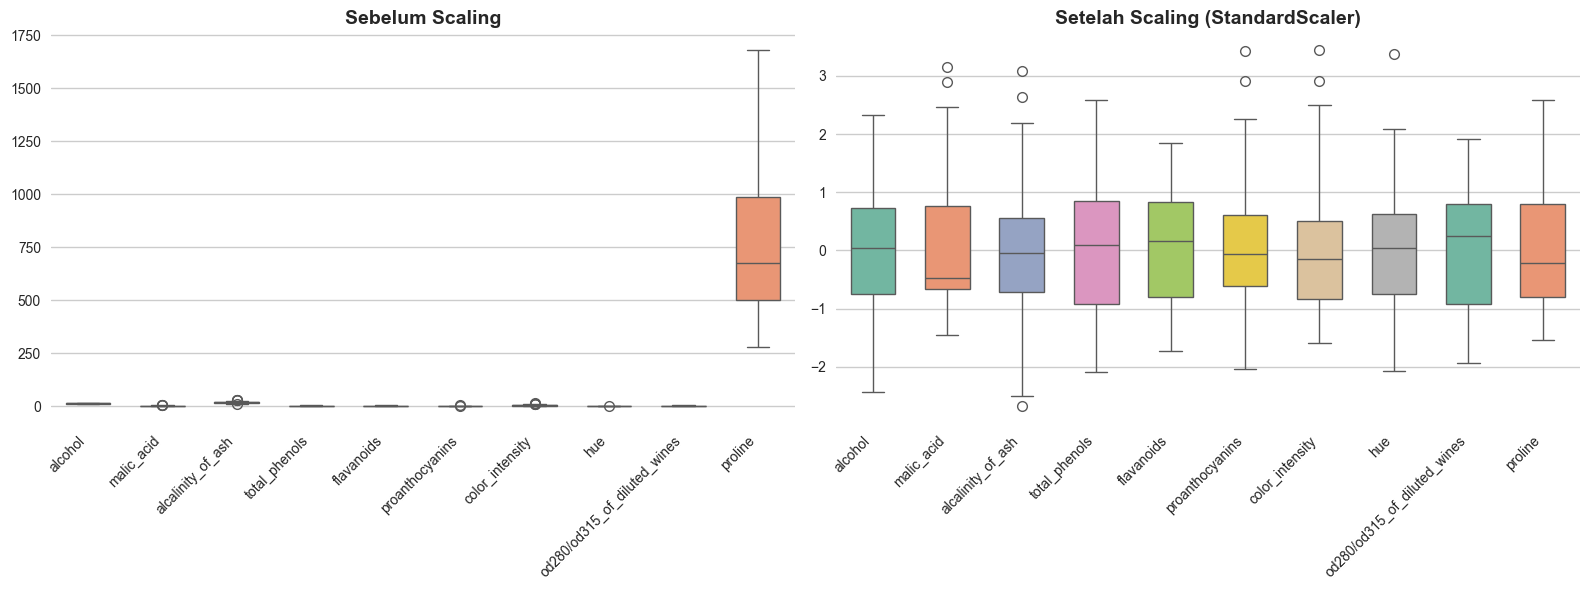

In [ ]:
# Standard Scaling
print("Standard Scaling:")
print("=" * 60)

scaler = StandardScaler()

# Fit hanya pada training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform pada testing data
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test = pd.DataFrame(X_test_scaled, columns=selected_features)

print("Statistik data training SETELAH scaling:")
print("-" * 40)
print(X_train.describe().round(4))

# Validasi scaling
print("\nValidasi Scaling (training set):")
print(f"  Rata-rata (mean) ~ 0 : {X_train.mean().mean():.6f}")
print(f"  Std dev (std) ~ 1    : {X_train.std().mean():.6f}")

# Visualisasi sebelum vs setelah scaling
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum scaling (gunakan data asli sebelum scaling)
X_before = df[selected_features]
sns.boxplot(data=X_before, ax=axes[0], palette="Set2", width=0.6)
axes[0].set_title("Sebelum Scaling", fontsize=14, fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

# Setelah scaling
sns.boxplot(data=X_train, ax=axes[1], palette="Set2", width=0.6)
axes[1].set_title("Setelah Scaling (StandardScaler)", fontsize=14, fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

---
### 5.3 Menyimpan Dataset Hasil Preprocessing

Menyimpan data yang sudah diproses ke dalam file CSV untuk digunakan pada tahap modelling.

In [ ]:
# Menyimpan dataset hasil preprocessing
import os

# Path folder preprocessing
preprocessing_dir = "../preprocessing"
os.makedirs(preprocessing_dir, exist_ok=True)

# Simpan ke CSV
X_train.to_csv(os.path.join(preprocessing_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(preprocessing_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(preprocessing_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(preprocessing_dir, "y_test.csv"), index=False)

print("Dataset hasil preprocessing berhasil disimpan!")
print("=" * 60)
print(f"  X_train.csv : {X_train.shape}")
print(f"  X_test.csv  : {X_test.shape}")
print(f"  y_train.csv : {y_train.shape}")
print(f"  y_test.csv  : {y_test.shape}")
print(f"\nLokasi: {os.path.abspath(preprocessing_dir)}")

Dataset hasil preprocessing berhasil disimpan!
  X_train.csv : (142, 10)
  X_test.csv  : (36, 10)
  y_train.csv : (142,)
  y_test.csv  : (36,)

Lokasi: e:\Dicoding\Membangun Sistem Machine Learning\Membangun Sistem Machine Learning\Eksperimen_SML_Ayudha\preprocessing


---
## Kesimpulan

### Insight Dataset

* Dataset **Wine** memiliki **178 sampel**, **13 fitur numerik**, dan **3 kelas target**.
* Tidak terdapat **missing values** maupun **data duplikat**.
* Distribusi kelas cukup seimbang, meskipun jumlah tiap kelas berbeda.
* Fitur yang paling berpengaruh terhadap target yaitu `flavanoids`, `total_phenols`, `color_intensity`, `od280/od315_of_diluted_wines`, dan `proline`.

### Hasil Preprocessing

* Dataset sudah bersih sehingga tidak memerlukan penanganan missing value maupun encoding.
* Outlier terdeteksi tetapi tetap dipertahankan.
* Dipilih **10 fitur terbaik** menggunakan `SelectKBest`.
* Data dibagi menjadi **80% training** dan **20% testing** dengan stratifikasi.
* Scaling dilakukan menggunakan `StandardScaler`.

### Kesiapan Modelling

Dataset siap digunakan untuk proses klasifikasi multiclass dengan algoritma seperti Random Forest, Support Vector Machine, dan Logistic Regression.
